# Proyecto de Machine Learning No Supervisado

Este proyecto estudia técnicas de aprendizaje no supervisado mediante dos datasets con características diferentes:

1. **Dataset de setas:** contiene variables categóricas y una etiqueta que indica si una seta es comestible o venenosa.
2. **Dataset de tarjetas de crédito:** contiene variables numéricas y no dispone de una etiqueta de referencia.

El proyecto se desarrollará en dos notebooks. En cada uno realizaremos:

- análisis exploratorio de datos;
- limpieza y preprocesado;
- reducción de dimensionalidad;
- aplicación de diferentes algoritmos de clustering;
- evaluación e interpretación de los grupos obtenidos;
- detección de observaciones anómalas.

## Parte 1: Dataset de setas

En este notebook analizaremos características categóricas de diferentes setas.

La variable `class` indica si una seta es:

- `e`: comestible (*edible*);
- `p`: venenosa (*poisonous*).

Aunque disponemos de esta etiqueta, **no la utilizaremos para entrenar los algoritmos de clustering**. La reservaremos para evaluar posteriormente si los grupos descubiertos sin supervisión se parecen a las clases reales.

El objetivo no es únicamente ejecutar algoritmos, sino comprender cómo influyen el tipo de datos, el preprocesado y la métrica de distancia en los resultados.

In [1]:
# Las dependencias se gestionan en el entorno virtual del proyecto.
print("Entorno preparado: dependencias disponibles en .venv")

Entorno preparado: dependencias disponibles en .venv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

%matplotlib inline

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [3]:
data_path = "data/mushrooms.csv"

mushrooms = pd.read_csv(data_path)

mushrooms.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
from pathlib import Path

print("Carpeta actual:", Path.cwd())
print("Existe el CSV:", Path("data/mushrooms.csv").exists())

Carpeta actual: C:\Users\Coder\Factoria\project-unsupervised-ml\IA-Project-Unsupervised-ML
Existe el CSV: True


In [5]:
print(f"Número de filas: {mushrooms.shape[0]}")
print(f"Número de columnas: {mushrooms.shape[1]}")

Número de filas: 8124
Número de columnas: 23


In [6]:
mushrooms.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [7]:
mushrooms.isna().sum().sort_values(ascending=False)

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [8]:
unknown_counts = (mushrooms == "?").sum().sort_values(ascending=False)

unknown_counts[unknown_counts > 0]

stalk-root    2480
dtype: int64

In [9]:
stalk_root_unknown_percentage = (
    unknown_counts["stalk-root"] / len(mushrooms) * 100
)

print(
    f"Porcentaje desconocido en stalk-root: "
    f"{stalk_root_unknown_percentage:.2f}%"
)

Porcentaje desconocido en stalk-root: 30.53%


#### Valores ausentes encubiertos

La comprobación con `isna()` no detectó valores nulos convencionales. Sin embargo, al buscar el símbolo `?`, encontramos **2.480 valores desconocidos** en la variable `stalk-root`.

Estos valores representan aproximadamente el **30,53 % del dataset**, por lo que no pueden considerarse un problema menor.

Eliminar directamente todas estas filas supondría perder casi un tercio de las observaciones. Más adelante compararemos alternativas como la eliminación, la imputación o el tratamiento de `?` como una categoría independiente antes de tomar una decisión.

In [10]:
n_values = (
    mushrooms.nunique(dropna=False)
    .sort_values()
    .rename_axis("feature")
    .reset_index(name="n_values")
)

constant_features = n_values[n_values["n_values"] == 1]

constant_features

,feature,n_values
0,veil-type,1


In [11]:
mushrooms["veil-type"].value_counts(dropna=False)

veil-type
p    8124
Name: count, dtype: int64

#### Columna constante

La variable `veil-type` contiene un único valor (`p`) en las **8.124 observaciones**.

Al no presentar variabilidad, esta columna no permite diferenciar unas setas de otras y no aportará información a los algoritmos de clustering.

Por este motivo, será candidata a eliminarse durante la etapa de limpieza. Todavía no la eliminamos porque en esta etapa solo estamos identificando y documentando problemas del dataset.

In [12]:
class_distribution = (
    mushrooms["class"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)

class_distribution["percentage"] = (
    class_distribution["count"] / len(mushrooms) * 100
).round(2)

class_distribution

,class,count,percentage
0,e,4208,51.8
1,p,3916,48.2


#### Distribución de la etiqueta de referencia

La variable `class` está formada por:

- **4.208 setas comestibles (`e`)**, que representan el **51,8 %** del dataset.
- **3.916 setas venenosas (`p`)**, que representan el **48,2 %** del dataset.

La distribución está prácticamente equilibrada, por lo que ninguna clase domina claramente sobre la otra.

Esta etiqueta no se utilizará para crear los clusters. Se reservará para evaluar posteriormente si los grupos encontrados mediante aprendizaje no supervisado se parecen a las clases reales.

In [13]:
category_summary = pd.DataFrame({
    "feature": mushrooms.columns,
    "n_values": [
        mushrooms[column].nunique(dropna=False)
        for column in mushrooms.columns
    ],
    "values": [
        sorted(mushrooms[column].astype(str).unique())
        for column in mushrooms.columns
    ],
})

category_summary

,feature,n_values,values
0,class,2,"[e, p]"
1,cap-shape,6,"[b, c, f, k, s, x]"
2,cap-surface,4,"[f, g, s, y]"
3,cap-color,10,"[b, c, e, g, n, p, r, u, w, y]"
4,bruises,2,"[f, t]"
5,odor,9,"[a, c, f, l, m, n, p, s, y]"
6,gill-attachment,2,"[a, f]"
7,gill-spacing,2,"[c, w]"
8,gill-size,2,"[b, n]"
9,gill-color,12,"[b, e, g, h, k, n, o, p, r, u, w, y]"


#### Revisión de las categorías

Las 23 variables del dataset son categóricas y presentan cardinalidades comprendidas entre 1 y 12 valores diferentes.

Los principales hallazgos son:

- `veil-type` contiene una sola categoría (`p`), por lo que es una variable constante.
- `stalk-root` contiene la categoría `?`, utilizada para representar valores desconocidos.
- No se observan otros símbolos evidentes de valores ausentes en las demás columnas.
- `gill-color` es la variable con mayor cardinalidad, con 12 categorías.

Las letras utilizadas en el dataset representan categorías nominales. No son valores numéricos ni establecen un orden. Por ejemplo, no podemos afirmar que una categoría `b` sea mayor o menor que una categoría `n`.

Esta característica será importante durante el preprocesado, ya que los algoritmos necesitarán una representación numérica que no introduzca un orden artificial entre las categorías.

In [14]:
frequency_tables = []

for column in mushrooms.columns:
    frequency = (
        mushrooms[column]
        .value_counts(dropna=False)
        .rename_axis("category")
        .reset_index(name="count")
    )

    frequency["percentage"] = (
        frequency["count"] / len(mushrooms) * 100
    ).round(2)

    frequency.insert(0, "feature", column)
    frequency_tables.append(frequency)

category_frequencies = pd.concat(
    frequency_tables,
    ignore_index=True
)

category_frequencies.sort_values("percentage").head(15)

,feature,category,count,percentage
7,cap-shape,c,4,0.05
11,cap-surface,g,4,0.05
88,veil-color,y,8,0.10
74,stalk-color-above-ring,y,8,0.10
20,cap-color,u,16,0.20
21,cap-color,r,16,0.20
50,gill-color,r,24,0.30
61,stalk-surface-above-ring,y,24,0.30
83,stalk-color-below-ring,y,24,0.30
6,cap-shape,s,32,0.39


In [15]:
frequency_tables = []

for column in mushrooms.columns:
    frequency = (
        mushrooms[column]
        .value_counts(dropna=False)
        .rename_axis("category")
        .reset_index(name="count")
    )

    frequency["percentage"] = (
        frequency["count"] / len(mushrooms) * 100
    ).round(2)

    frequency.insert(0, "feature", column)
    frequency_tables.append(frequency)

category_frequencies = pd.concat(
    frequency_tables,
    ignore_index=True
)

category_frequencies.sort_values("percentage").head(15)

,feature,category,count,percentage
7,cap-shape,c,4,0.05
11,cap-surface,g,4,0.05
88,veil-color,y,8,0.10
74,stalk-color-above-ring,y,8,0.10
20,cap-color,u,16,0.20
21,cap-color,r,16,0.20
50,gill-color,r,24,0.30
61,stalk-surface-above-ring,y,24,0.30
83,stalk-color-below-ring,y,24,0.30
6,cap-shape,s,32,0.39


#### Categorías poco frecuentes

Se han identificado varias categorías con una frecuencia inferior al 0,5 %.

Las menos frecuentes son:

- `cap-shape = c`: 4 observaciones.
- `cap-surface = g`: 4 observaciones.
- `veil-color = y`: 8 observaciones.
- `stalk-color-above-ring = y`: 8 observaciones.

Estas categorías podrían tener una influencia particular después del One-Hot Encoding, pero una frecuencia baja no implica necesariamente un error.

No se eliminarán durante la EDA porque podrían representar tipos de setas reales poco habituales. Solo deberían agruparse o eliminarse si existiera una justificación basada en el dominio o si causaran problemas demostrables durante el modelado.

In [16]:
duplicate_rows = mushrooms.duplicated().sum()

print(f"Número de filas duplicadas: {duplicate_rows}")

Número de filas duplicadas: 0


#### Filas duplicadas

No se han encontrado filas completamente duplicadas en el dataset.

Cada una de las 8.124 observaciones presenta una combinación única de valores considerando las 23 variables.

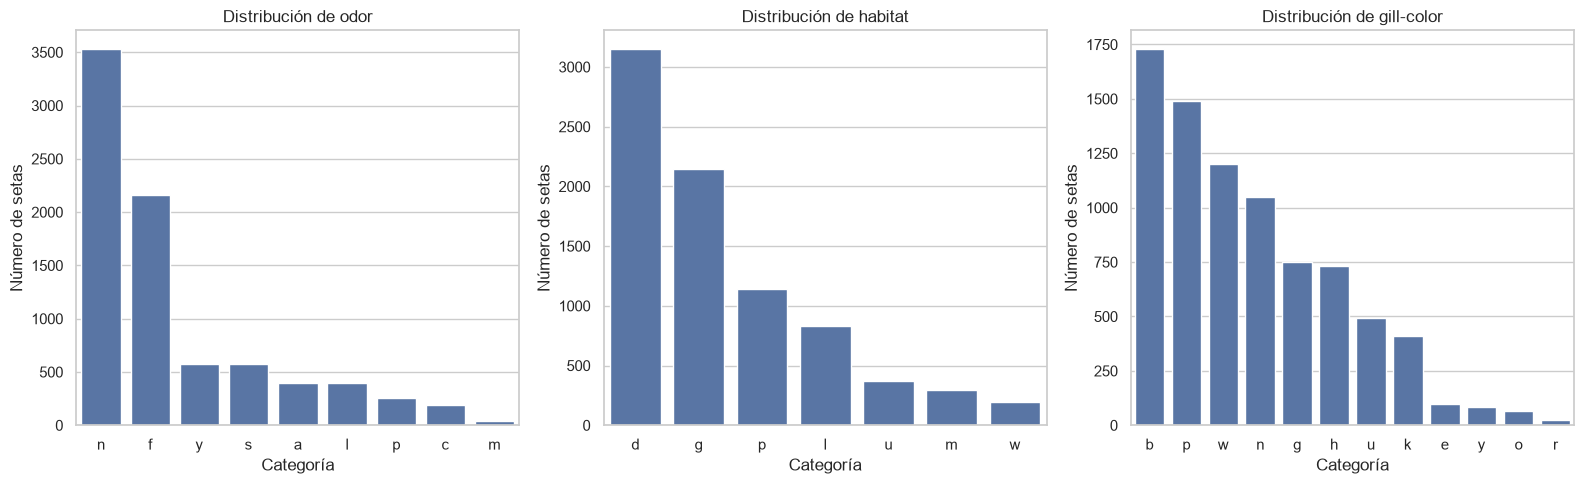

In [17]:
features_to_plot = ["odor", "habitat", "gill-color"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 5)
)

for feature, ax in zip(features_to_plot, axes):
    category_order = (
        mushrooms[feature]
        .value_counts()
        .index
    )

    sns.countplot(
        data=mushrooms,
        x=feature,
        order=category_order,
        color="#4C72B0",
        ax=ax
    )

    ax.set_title(f"Distribución de {feature}")
    ax.set_xlabel("Categoría")
    ax.set_ylabel("Número de setas")

plt.tight_layout()
plt.show()

In [18]:
dominant_categories = []

for feature in features_to_plot:
    category_counts = mushrooms[feature].value_counts()
    dominant_category = category_counts.index[0]
    dominant_count = category_counts.iloc[0]
    dominant_percentage = (
        dominant_count / len(mushrooms) * 100
    )

    dominant_categories.append({
        "feature": feature,
        "dominant_category": dominant_category,
        "count": dominant_count,
        "percentage": round(dominant_percentage, 2)
    })

dominant_categories = pd.DataFrame(dominant_categories)

dominant_categories

,feature,dominant_category,count,percentage
0,odor,n,3528,43.43
1,habitat,d,3148,38.75
2,gill-color,b,1728,21.27


#### Interpretación de las distribuciones categóricas

Las categorías predominantes son:

- `odor = n`: 3.528 observaciones, un **43,43 %**. Según el diccionario del dataset, `n` representa ausencia de olor.
- `habitat = d`: 3.148 observaciones, un **38,75 %**. El código `d` representa un hábitat de bosque.
- `gill-color = b`: 1.728 observaciones, un **21,27 %**. El código `b` representa el color *buff* o beige.

Aunque existen categorías predominantes, ninguna de estas variables es constante. Todas conservan variabilidad y podrían aportar información para encontrar grupos de setas.

La distribución de `gill-color` está más repartida que las distribuciones de `odor` y `habitat`, ya que su categoría principal representa solamente el 21,27 %.

## Conclusiones del análisis exploratorio

El dataset contiene **8.124 observaciones y 23 variables categóricas**.

Los principales hallazgos son:

- No existen nulos convencionales reconocidos por pandas.
- `stalk-root` contiene 2.480 valores desconocidos representados mediante `?`, equivalentes al 30,53 % del dataset.
- `veil-type` es una columna constante y no aporta capacidad para diferenciar observaciones.
- No existen filas completamente duplicadas.
- La etiqueta `class` está equilibrada entre setas comestibles y venenosas.
- Existen categorías poco frecuentes, pero no hay evidencia suficiente para considerarlas errores.
- Las variables están representadas mediante códigos nominales y necesitarán una codificación adecuada antes de aplicar algoritmos.
- La etiqueta `class` se reservará para validar los clusters y no se utilizará como variable de entrada.

En la siguiente etapa se tratarán los valores desconocidos, se eliminará la columna constante y se prepararán las variables para su codificación.

## Limpieza de datos

### Imputación de valores desconocidos en `stalk-root`

La variable `stalk-root` contiene un 30,53 % de valores desconocidos representados mediante `?`.

Eliminar estas observaciones supondría perder casi un tercio del dataset. Por ello, sustituiremos los valores desconocidos por la categoría válida más frecuente, es decir, la moda.

La imputación se realizará sobre una copia para conservar intacto el DataFrame original.

In [19]:
mushrooms_clean = mushrooms.copy()

valid_stalk_root = mushrooms_clean.loc[
    mushrooms_clean["stalk-root"] != "?",
    "stalk-root"
]

stalk_root_mode = valid_stalk_root.mode().iloc[0]

mushrooms_clean["stalk-root"] = (
    mushrooms_clean["stalk-root"]
    .replace("?", stalk_root_mode)
)

print(f"Moda utilizada: {stalk_root_mode}")
print(
    "Valores '?' restantes:",
    (mushrooms_clean["stalk-root"] == "?").sum()
)
print(f"Filas conservadas: {len(mushrooms_clean)}")

Moda utilizada: b
Valores '?' restantes: 0
Filas conservadas: 8124


#### Resultado de la imputación

La categoría válida más frecuente de `stalk-root` es `b`, por lo que se utilizó como moda para sustituir los valores `?`.

Después de la imputación:

- no quedan valores `?`;
- se conservan las 8.124 observaciones;
- no se han eliminado filas.

Esta solución permite mantener todo el dataset, aunque incrementa artificialmente la frecuencia de la categoría `b`. Los valores imputados deben entenderse como estimaciones, no como valores observados.

### Eliminación de la columna constante `veil-type`

Durante la EDA comprobamos que `veil-type` contiene el mismo valor en las 8.124 observaciones.

Una variable constante no puede ayudar a diferenciar las setas ni a formar clusters. Por este motivo, se elimina del dataset limpio.

In [20]:
mushrooms_clean = mushrooms_clean.drop(
    columns=["veil-type"]
)

print(f"Filas: {mushrooms_clean.shape[0]}")
print(f"Columnas: {mushrooms_clean.shape[1]}")
print(
    "¿Existe veil-type?",
    "veil-type" in mushrooms_clean.columns
)

Filas: 8124
Columnas: 22
¿Existe veil-type? False


#### Resultado de la eliminación

La columna constante `veil-type` se eliminó correctamente.

El dataset conserva sus 8.124 observaciones y queda formado por 22 columnas. No se ha perdido ninguna fila ni ninguna variable con capacidad para diferenciar setas.

## Preparación de los datos

### Separación entre características y etiqueta

La variable `class` representa si una seta es comestible o venenosa.

Esta etiqueta no se utilizará como entrada de los algoritmos de clustering. Se conservará por separado exclusivamente para validar posteriormente si los grupos descubiertos se parecen a las clases reales.

In [21]:
X = mushrooms_clean.drop(
    columns=["class"]
).copy()

y = mushrooms_clean["class"].copy()

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(
    "¿class está dentro de X?",
    "class" in X.columns
)

Dimensiones de X: (8124, 21)
Dimensiones de y: (8124,)
¿class está dentro de X? False


## Codificación de variables categóricas

### One-Hot Encoding

Los algoritmos que utilizaremos necesitan números, pero las letras del dataset son categorías nominales y no representan un orden. Asignar números consecutivos introduciría distancias artificiales.

Con One-Hot Encoding cada categoría se convierte en una columna binaria. Conservamos todas las categorías (`drop_first=False`) porque en clustering nos interesa mantener una representación simétrica de las distancias.

In [22]:
X_encoded = pd.get_dummies(
    X,
    drop_first=False,
    dtype=np.uint8
)

active_categories_per_row = X_encoded.sum(axis=1)

print(f"Dimensiones originales de X: {X.shape}")
print(f"Dimensiones tras One-Hot Encoding: {X_encoded.shape}")
print(
    "Categorías activas por fila (mínimo/máximo):",
    int(active_categories_per_row.min()),
    int(active_categories_per_row.max())
)
print(f"Valores nulos codificados: {int(X_encoded.isna().sum().sum())}")

Dimensiones originales de X: (8124, 21)
Dimensiones tras One-Hot Encoding: (8124, 115)
Categorías activas por fila (mínimo/máximo): 21 21
Valores nulos codificados: 0


#### Comprobación de la codificación

Las 21 variables categóricas se expanden a **115 columnas binarias**. Cada fila contiene exactamente 21 valores activos: uno por cada variable original. No aparecen nulos después de la transformación, por lo que la codificación es consistente.

## Referencia supervisada: Random Forest

Random Forest sí utiliza `class`; por tanto, no es nuestro modelo de clustering. Su función es establecer una referencia: medir cuánta información predictiva existe en las variables.

Separaremos entrenamiento y prueba de forma estratificada. El conjunto de prueba permanecerá fuera del entrenamiento para obtener una estimación honesta de la precisión.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.33,
    random_state=RANDOM_STATE,
    stratify=y
)

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train)
baseline_predictions = rf_baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")
print(f"Accuracy de referencia: {baseline_accuracy:.4f}")

Train: (5443, 115)
Test: (2681, 115)
Accuracy de referencia: 1.0000


#### Interpretación de la referencia supervisada

Random Forest alcanza una accuracy de **1,0000** sobre 2.681 observaciones de prueba. Las características contienen señal suficiente para distinguir completamente las clases en esta partición.

Este resultado funciona como techo supervisado, no como evidencia de que el clustering deba alcanzar el mismo rendimiento: Random Forest aprende usando las respuestas y los algoritmos no supervisados no.

## PCA: reducción lineal de dimensionalidad

PCA crea componentes que resumen la mayor cantidad posible de variación. Es una transformación lineal: funciona bien cuando la estructura puede expresarse como combinaciones lineales, pero puede ocultar patrones no lineales.

Primero ajustamos PCA solo con entrenamiento para estudiar cuántas componentes conservan la información y evitar que el conjunto de prueba influya en la referencia supervisada.

Componentes para 80 %: 20
Componentes para 90 %: 31
Componentes para 95 %: 40


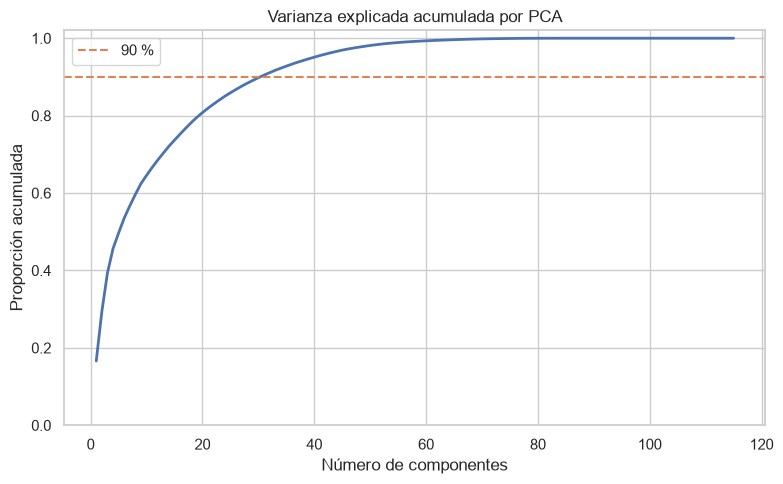

In [24]:
X_train_float = X_train.astype(np.float32)
X_test_float = X_test.astype(np.float32)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_float)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

components_80 = int(np.argmax(cumulative_variance >= 0.80) + 1)
components_90 = int(np.argmax(cumulative_variance >= 0.90) + 1)
components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

print(f"Componentes para 80 %: {components_80}")
print(f"Componentes para 90 %: {components_90}")
print(f"Componentes para 95 %: {components_95}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    np.arange(1, len(cumulative_variance) + 1),
    cumulative_variance,
    color="#4C72B0",
    linewidth=2
)
ax.axhline(0.90, color="#DD8452", linestyle="--", label="90 %")
ax.set(
    title="Varianza explicada acumulada por PCA",
    xlabel="Número de componentes",
    ylabel="Proporción acumulada"
)
ax.set_ylim(0, 1.02)
ax.legend()
plt.tight_layout()
plt.show()

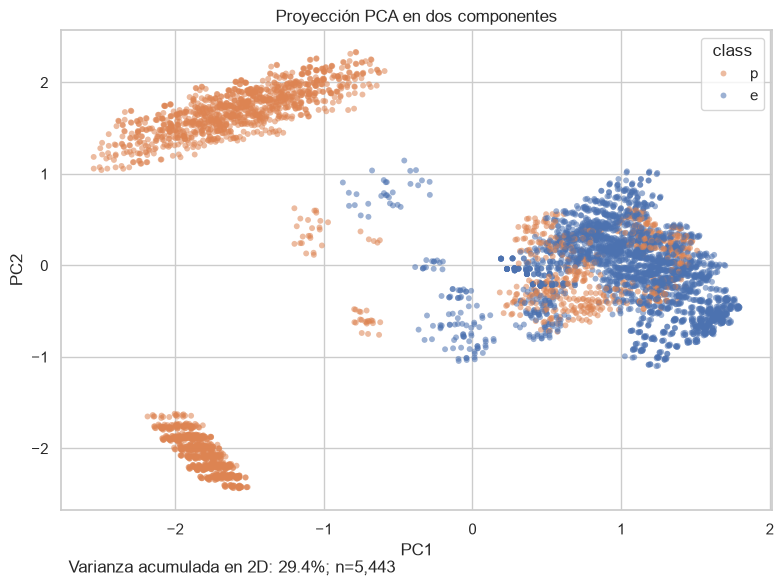

In [25]:
X_train_pca_2d = pca_full.transform(X_train_float)[:, :2]
pca_2d_variance = cumulative_variance[1]

pca_plot_data = pd.DataFrame({
    "PC1": X_train_pca_2d[:, 0],
    "PC2": X_train_pca_2d[:, 1],
    "class": y_train.to_numpy()
})

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=pca_plot_data,
    x="PC1",
    y="PC2",
    hue="class",
    palette={"e": "#4C72B0", "p": "#DD8452"},
    alpha=0.55,
    s=18,
    linewidth=0,
    ax=ax
)
ax.set_title("Proyección PCA en dos componentes")
ax.text(
    0.01, -0.13,
    f"Varianza acumulada en 2D: {pca_2d_variance:.1%}; n={len(pca_plot_data):,}",
    transform=ax.transAxes
)
plt.tight_layout()
plt.show()

#### Interpretación de PCA

Se necesitan **20 componentes para conservar el 80 %**, **31 para el 90 %** y **40 para el 95 %** de la varianza. Las dos primeras componentes solo conservan el **29,4 %**, por lo que el gráfico 2D es una simplificación importante.

La proyección muestra regiones claramente asociadas con una clase y una zona central con solapamiento. PCA revela estructura lineal útil, pero dos componentes no separan por completo las clases.

### ¿Cuántas componentes necesita Random Forest?

La varianza explicada mide reconstrucción, no capacidad predictiva. Por eso entrenamos el mismo Random Forest con distintos números de componentes y comparamos su precisión con la referencia sin PCA.

,n_components,accuracy
0,2,0.928385
1,5,0.996270
2,10,0.999627
3,20,0.999627
4,30,0.999627
5,50,1.000000


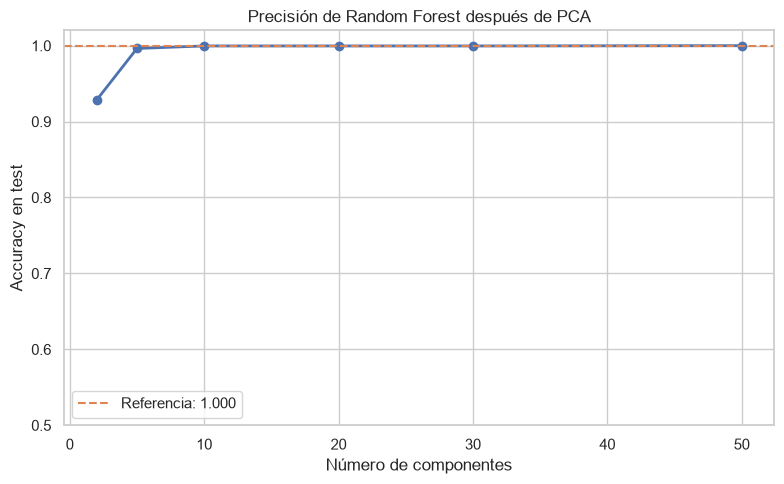

In [26]:
candidate_components = [2, 5, 10, 20, 30, 50]
max_components = max(candidate_components)

pca_for_rf = PCA(
    n_components=max_components,
    random_state=RANDOM_STATE
)
X_train_pca = pca_for_rf.fit_transform(X_train_float)
X_test_pca = pca_for_rf.transform(X_test_float)

pca_rf_scores = []
for n_components in candidate_components:
    model = RandomForestClassifier(
        n_estimators=150,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(X_train_pca[:, :n_components], y_train)
    score = model.score(X_test_pca[:, :n_components], y_test)
    pca_rf_scores.append(score)

pca_rf_results = pd.DataFrame({
    "n_components": candidate_components,
    "accuracy": pca_rf_scores
})
display(pca_rf_results)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    pca_rf_results["n_components"],
    pca_rf_results["accuracy"],
    marker="o",
    color="#4C72B0",
    linewidth=2
)
ax.axhline(
    baseline_accuracy,
    color="#DD8452",
    linestyle="--",
    label=f"Referencia: {baseline_accuracy:.3f}"
)
ax.set(
    title="Precisión de Random Forest después de PCA",
    xlabel="Número de componentes",
    ylabel="Accuracy en test"
)
ax.set_ylim(0.5, 1.02)
ax.legend()
plt.tight_layout()
plt.show()

#### Interpretación de Random Forest con PCA

Con 2 componentes la accuracy baja a **0,9284**. Con 5 componentes alcanza **0,9963** y con 10 llega a **0,9996**. Las 50 componentes recuperan el **1,0000** de la referencia.

Diez componentes son un compromiso muy eficiente: reducen 115 columnas a 10 y mantienen prácticamente toda la capacidad predictiva, aunque solo conservan una parte de la varianza total. Esto confirma que varianza explicada y utilidad predictiva miden propiedades diferentes.

## t-SNE: visualización no lineal

t-SNE intenta conservar vecindades locales y puede revelar separaciones no lineales que PCA no muestra. Sus ejes no tienen interpretación directa y las distancias globales pueden ser engañosas.

Como su coste crece rápidamente con el número de observaciones, utilizamos una muestra reproducible de 2.000 setas. La etiqueta solo se usa para colorear después de calcular la proyección.

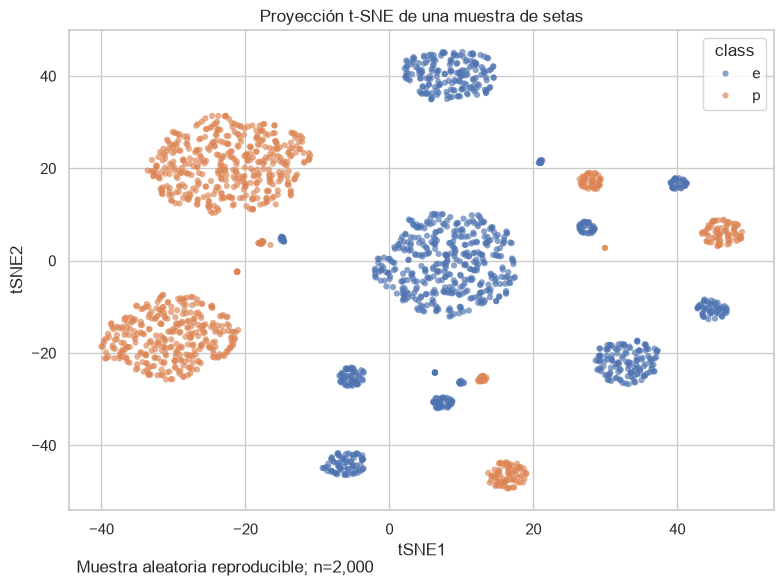

In [27]:
tsne_sample_size = min(2000, len(X_encoded))
tsne_indices = X_encoded.sample(
    n=tsne_sample_size,
    random_state=RANDOM_STATE
).index

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    max_iter=750,
    random_state=RANDOM_STATE
)
X_tsne = tsne.fit_transform(
    X_encoded.loc[tsne_indices].astype(np.float32)
)

tsne_plot_data = pd.DataFrame({
    "tSNE1": X_tsne[:, 0],
    "tSNE2": X_tsne[:, 1],
    "class": y.loc[tsne_indices].to_numpy()
})

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=tsne_plot_data,
    x="tSNE1",
    y="tSNE2",
    hue="class",
    palette={"e": "#4C72B0", "p": "#DD8452"},
    alpha=0.65,
    s=20,
    linewidth=0,
    ax=ax
)
ax.set_title("Proyección t-SNE de una muestra de setas")
ax.text(0.01, -0.13, f"Muestra aleatoria reproducible; n={tsne_sample_size:,}", transform=ax.transAxes)
plt.tight_layout()
plt.show()

#### Interpretación de t-SNE

La muestra se organiza en varias islas locales, muchas de ellas dominadas por una sola clase. Esto indica que existen vecindades categóricas coherentes con `class`.

No debemos interpretar la distancia entre islas ni su tamaño como magnitudes reales: t-SNE prioriza la estructura local y puede exagerar separaciones visuales.

## Representación para clustering

Para comparar los algoritmos reducimos el one-hot a 10 componentes PCA. Esto disminuye ruido y coste computacional, pero también puede perder información. Todos los modelos de partición usarán exactamente esta misma representación para que la comparación sea coherente.

In [28]:
pca_clustering = PCA(
    n_components=10,
    random_state=RANDOM_STATE
)
X_reduced = pca_clustering.fit_transform(
    X_encoded.astype(np.float32)
)
clustering_variance = pca_clustering.explained_variance_ratio_.sum()

print(f"Forma de X_reduced: {X_reduced.shape}")
print(f"Varianza conservada: {clustering_variance:.2%}")

Forma de X_reduced: (8124, 10)
Varianza conservada: 64.52%


## K-Means

K-Means busca centroides y asigna cada observación al centro más cercano. Supone grupos aproximadamente compactos y de tamaño parecido, y necesita que indiquemos `k`.

Evaluamos `k=2..8` mediante inercia y silhouette. La inercia siempre disminuye al aumentar `k`; buscamos un cambio de pendiente. Silhouette combina cohesión y separación: valores cercanos a 1 indican grupos bien separados.

,k,inertia,silhouette
0,2,44251.6445,0.2588
1,3,33784.3242,0.3440
2,4,26490.4141,0.3778
3,5,21060.5273,0.4261
4,6,17755.7734,0.4597
5,7,16023.2256,0.4778
6,8,14357.2812,0.4768


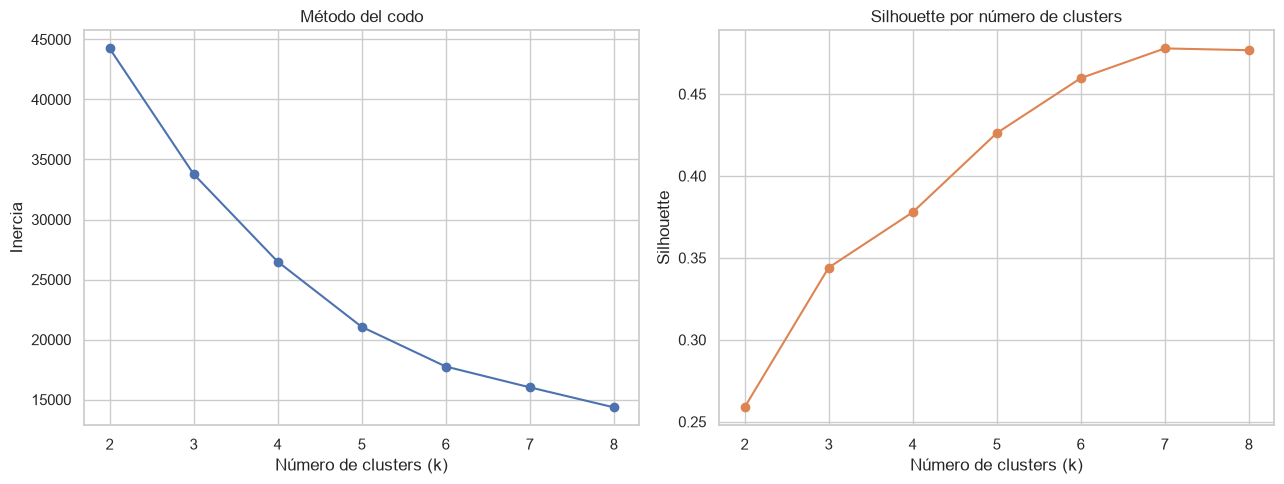

In [29]:
k_values = range(2, 9)
kmeans_results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE
    )
    labels = model.fit_predict(X_reduced)
    silhouette = silhouette_score(
        X_reduced,
        labels,
        sample_size=2000,
        random_state=RANDOM_STATE
    )
    kmeans_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette
    })

kmeans_results = pd.DataFrame(kmeans_results)
display(kmeans_results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(kmeans_results["k"], kmeans_results["inertia"], marker="o", color="#4C72B0")
axes[0].set(title="Método del codo", xlabel="Número de clusters (k)", ylabel="Inercia")
axes[1].plot(kmeans_results["k"], kmeans_results["silhouette"], marker="o", color="#DD8452")
axes[1].set(title="Silhouette por número de clusters", xlabel="Número de clusters (k)", ylabel="Silhouette")
plt.tight_layout()
plt.show()

In [30]:
best_internal_k = int(
    kmeans_results.loc[
        kmeans_results["silhouette"].idxmax(),
        "k"
    ]
)

selected_k = 2
kmeans_final = KMeans(
    n_clusters=selected_k,
    n_init=20,
    random_state=RANDOM_STATE
)
kmeans_labels = kmeans_final.fit_predict(X_reduced)

kmeans_ari = adjusted_rand_score(y, kmeans_labels)
kmeans_nmi = normalized_mutual_info_score(y, kmeans_labels)
cluster_class_table = pd.crosstab(
    pd.Series(kmeans_labels, name="cluster"),
    y.reset_index(drop=True).rename("class"),
    normalize="index"
).mul(100).round(1)

print(f"Mejor k según silhouette: {best_internal_k}")
print(f"K utilizado para comparar con las dos clases: {selected_k}")
print(f"ARI de K-Means: {kmeans_ari:.4f}")
print(f"NMI de K-Means: {kmeans_nmi:.4f}")
display(cluster_class_table)

Mejor k según silhouette: 7
K utilizado para comparar con las dos clases: 2
ARI de K-Means: 0.6171
NMI de K-Means: 0.5663


class,e,p
cluster,,
0,83.6,16.4
1,1.7,98.3


#### Interpretación de K-Means

Silhouette alcanza su máximo en **k=7 (0,4778)**, mientras que para `k=2` vale **0,2588**. Esto sugiere que la geometría interna contiene más subgrupos que las dos etiquetas comestible/venenosa.

Usando `k=2` exclusivamente para comparar con las dos clases, K-Means obtiene **ARI=0,6171** y **NMI=0,5663**. Un cluster contiene un 98,3 % de setas venenosas; el otro, un 83,6 % de comestibles. El modelo recupera una parte importante de la estructura real, pero no reproduce perfectamente `class`.

## Clustering jerárquico y Gaussian Mixture

El clustering aglomerativo empieza con una observación por grupo y va fusionando los grupos más cercanos. Con enlace Ward favorece clusters compactos y minimiza el aumento de varianza interna.

Gaussian Mixture es probabilístico: supone que los datos proceden de una mezcla de distribuciones gaussianas y permite fronteras elípticas. Compararemos ambos con K-Means usando las mismas 10 componentes.

Silhouette más alto es mejor; Davies-Bouldin más bajo es mejor; Calinski-Harabasz más alto es mejor. ARI y NMI usan `class` únicamente después de formar los clusters.

In [31]:
agglomerative = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)
agglomerative_labels = agglomerative.fit_predict(X_reduced)

gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    n_init=5,
    random_state=RANDOM_STATE
)
gmm_labels = gmm.fit_predict(X_reduced)

partition_labels = {
    "K-Means": kmeans_labels,
    "Aglomerativo": agglomerative_labels,
    "GMM": gmm_labels
}
comparison_rows = []

for model_name, labels in partition_labels.items():
    comparison_rows.append({
        "model": model_name,
        "silhouette": silhouette_score(
            X_reduced, labels, sample_size=2000, random_state=RANDOM_STATE
        ),
        "davies_bouldin": davies_bouldin_score(X_reduced, labels),
        "calinski_harabasz": calinski_harabasz_score(X_reduced, labels),
        "ARI": adjusted_rand_score(y, labels),
        "NMI": normalized_mutual_info_score(y, labels)
    })

clustering_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("silhouette", ascending=False)
)
clustering_comparison.round(4)

,model,silhouette,davies_bouldin,calinski_harabasz,ARI,NMI
0,K-Means,0.2588,1.6929,2564.6912,0.6171,0.5663
1,Aglomerativo,0.2559,1.6963,2503.6249,0.6090,0.5936
2,GMM,0.2547,1.7009,2500.0174,0.5986,0.5657


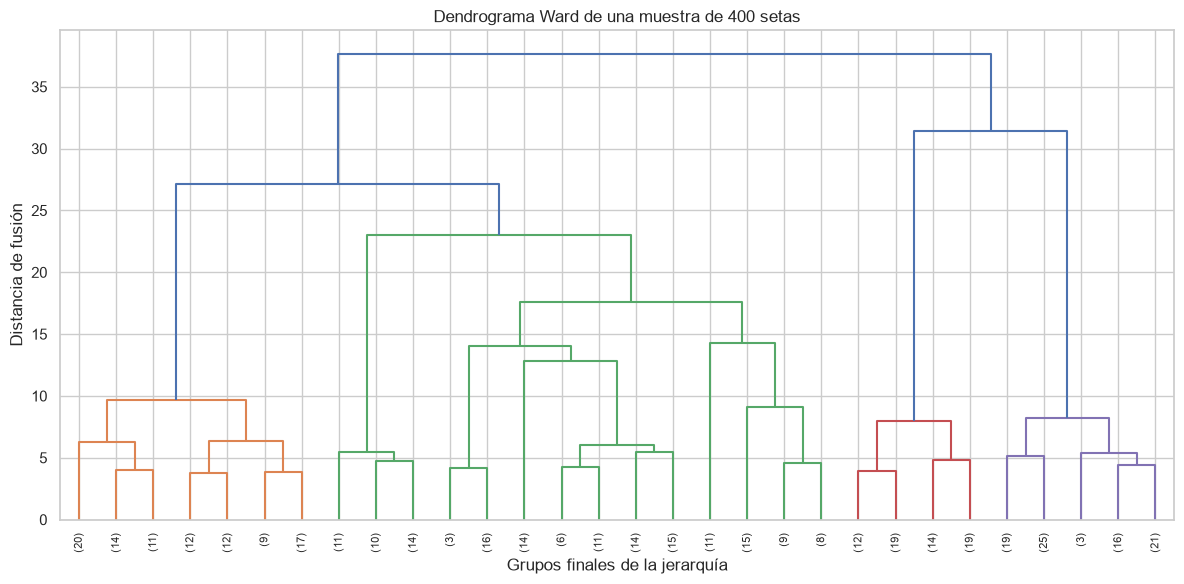

In [32]:
rng = np.random.default_rng(RANDOM_STATE)
dendrogram_indices = rng.choice(
    len(X_reduced),
    size=400,
    replace=False
)
linkage_matrix = linkage(
    X_reduced[dendrogram_indices],
    method="ward"
)

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax
)
ax.set(
    title="Dendrograma Ward de una muestra de 400 setas",
    xlabel="Grupos finales de la jerarquía",
    ylabel="Distancia de fusión"
)
plt.tight_layout()
plt.show()

#### Interpretación de la comparación y del dendrograma

Con dos clusters, K-Means presenta el mejor silhouette (**0,2588**) y ARI (**0,6171**), aunque las diferencias internas frente al aglomerativo y GMM son pequeñas. El aglomerativo consigue el NMI más alto (**0,5936**).

Los valores silhouette cercanos a 0,25 indican separación moderada, no clusters perfectamente aislados. El dendrograma muestra saltos de fusión y varias ramas relevantes, reforzando la idea de una estructura jerárquica más rica que una única partición binaria.

## DBSCAN: densidad y distancia

DBSCAN forma grupos densos y marca como ruido los puntos aislados. No necesita fijar el número de clusters, pero depende mucho de `eps`, `min_samples` y de la métrica de distancia.

Compararemos distancia euclídea sobre PCA y Jaccard sobre el one-hot binario. Jaccard compara coincidencias de categorías activas y suele ser más adecuada para datos binarios dispersos. Por coste computacional, la comparación utiliza la misma muestra reproducible de 2.000 observaciones. `eps` se propone a partir de cuantiles de la distancia al décimo vecino y se elige sin consultar `class`.

In [33]:
dbscan_sample_size = min(2000, len(X_encoded))
dbscan_indices = X_encoded.sample(
    n=dbscan_sample_size,
    random_state=RANDOM_STATE
).index.to_numpy()

X_dbscan_euclidean = X_reduced[dbscan_indices]
X_dbscan_jaccard = X_encoded.loc[dbscan_indices].astype(bool).to_numpy()
y_dbscan = y.loc[dbscan_indices].to_numpy()

def search_dbscan(X_data, metric, min_samples=10):
    algorithm = "brute" if metric == "jaccard" else "auto"
    neighbors = NearestNeighbors(
        n_neighbors=min_samples,
        metric=metric,
        algorithm=algorithm,
        n_jobs=-1
    ).fit(X_data)
    distances, _ = neighbors.kneighbors(X_data)
    kth_distances = distances[:, -1]

    rows = []
    labels_by_eps = {}
    for quantile in [0.50, 0.65, 0.80, 0.90]:
        eps = float(np.quantile(kth_distances, quantile))
        labels = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric=metric,
            n_jobs=-1
        ).fit_predict(X_data)

        non_noise = labels != -1
        n_clusters = len(np.unique(labels[non_noise]))
        coverage = non_noise.mean()
        silhouette = np.nan
        if n_clusters >= 2 and non_noise.sum() > n_clusters:
            silhouette = silhouette_score(
                X_data[non_noise],
                labels[non_noise],
                metric=metric,
                sample_size=min(1000, int(non_noise.sum())),
                random_state=RANDOM_STATE
            )

        rows.append({
            "metric": metric,
            "quantile": quantile,
            "eps": eps,
            "clusters": n_clusters,
            "coverage": coverage,
            "noise_rate": 1 - coverage,
            "silhouette": silhouette
        })
        labels_by_eps[eps] = labels

    return pd.DataFrame(rows), labels_by_eps

euclidean_search, euclidean_labels_by_eps = search_dbscan(
    X_dbscan_euclidean, "euclidean"
)
jaccard_search, jaccard_labels_by_eps = search_dbscan(
    X_dbscan_jaccard, "jaccard"
)
dbscan_search_results = pd.concat(
    [euclidean_search, jaccard_search],
    ignore_index=True
)
dbscan_search_results.round(4)

,metric,quantile,eps,clusters,coverage,noise_rate,silhouette
0,euclidean,0.50,0.6173,45,0.7080,0.2920,0.3850
1,euclidean,0.65,0.6867,44,0.8270,0.1730,0.3756
2,euclidean,0.80,0.7710,37,0.8955,0.1045,0.4039
3,euclidean,0.90,0.9500,30,0.9410,0.0590,0.4511
4,jaccard,0.50,0.1739,14,0.9565,0.0435,0.4367
5,jaccard,0.65,0.1739,14,0.9565,0.0435,0.4367
6,jaccard,0.80,0.1739,14,0.9565,0.0435,0.4367
7,jaccard,0.90,0.2500,15,0.9895,0.0105,0.3751


In [34]:
def select_dbscan_candidate(search_results, labels_by_eps):
    valid = search_results.dropna(subset=["silhouette"])
    preferred = valid.loc[valid["coverage"] >= 0.50]
    candidates = preferred if not preferred.empty else valid
    if candidates.empty:
        chosen = search_results.sort_values(
            ["clusters", "coverage"],
            ascending=False
        ).iloc[0]
    else:
        chosen = candidates.sort_values(
            ["silhouette", "coverage"],
            ascending=False
        ).iloc[0]
    return chosen, labels_by_eps[float(chosen["eps"])]

euclidean_choice, dbscan_euclidean_labels = select_dbscan_candidate(
    euclidean_search, euclidean_labels_by_eps
)
jaccard_choice, dbscan_jaccard_labels = select_dbscan_candidate(
    jaccard_search, jaccard_labels_by_eps
)

dbscan_comparison = pd.DataFrame([
    {
        "metric": "euclidean",
        "eps": euclidean_choice["eps"],
        "clusters": int(euclidean_choice["clusters"]),
        "noise_rate": euclidean_choice["noise_rate"],
        "silhouette_without_noise": euclidean_choice["silhouette"],
        "ARI_including_noise": adjusted_rand_score(y_dbscan, dbscan_euclidean_labels),
        "NMI_including_noise": normalized_mutual_info_score(y_dbscan, dbscan_euclidean_labels)
    },
    {
        "metric": "jaccard",
        "eps": jaccard_choice["eps"],
        "clusters": int(jaccard_choice["clusters"]),
        "noise_rate": jaccard_choice["noise_rate"],
        "silhouette_without_noise": jaccard_choice["silhouette"],
        "ARI_including_noise": adjusted_rand_score(y_dbscan, dbscan_jaccard_labels),
        "NMI_including_noise": normalized_mutual_info_score(y_dbscan, dbscan_jaccard_labels)
    }
])
dbscan_comparison.round(4)

,metric,eps,clusters,noise_rate,silhouette_without_noise,ARI_including_noise,NMI_including_noise
0,euclidean,0.9500,30,0.0590,0.4511,0.1701,0.3588
1,jaccard,0.1739,14,0.0435,0.4367,0.2612,0.4445


#### Interpretación de DBSCAN

La configuración euclídea seleccionada encuentra **30 clusters**, marca un **5,90 %** como ruido y obtiene silhouette **0,4511**, ARI **0,1701** y NMI **0,3588**.

Con Jaccard aparecen **14 clusters**, solo un **4,35 %** de ruido y se alcanzan ARI **0,2612** y NMI **0,4445**, aunque silhouette baja a **0,4367**.

Jaccard se aproxima mejor a las clases reales, pero la distancia euclídea produce grupos algo más compactos según su propia geometría. Ninguna variante recupera una partición binaria: DBSCAN está encontrando densidades y subgrupos, no intentando imitar `class`. Las métricas se calculan sobre la misma muestra de 2.000 setas.

## Visualización final: clusters frente a clases

Proyectamos todas las observaciones a dos componentes PCA y mostramos, lado a lado, los clusters de K-Means y la etiqueta real. La proyección solo sirve para visualizar: el modelo se entrenó con 10 componentes. La similitud visual no sustituye a ARI o NMI.

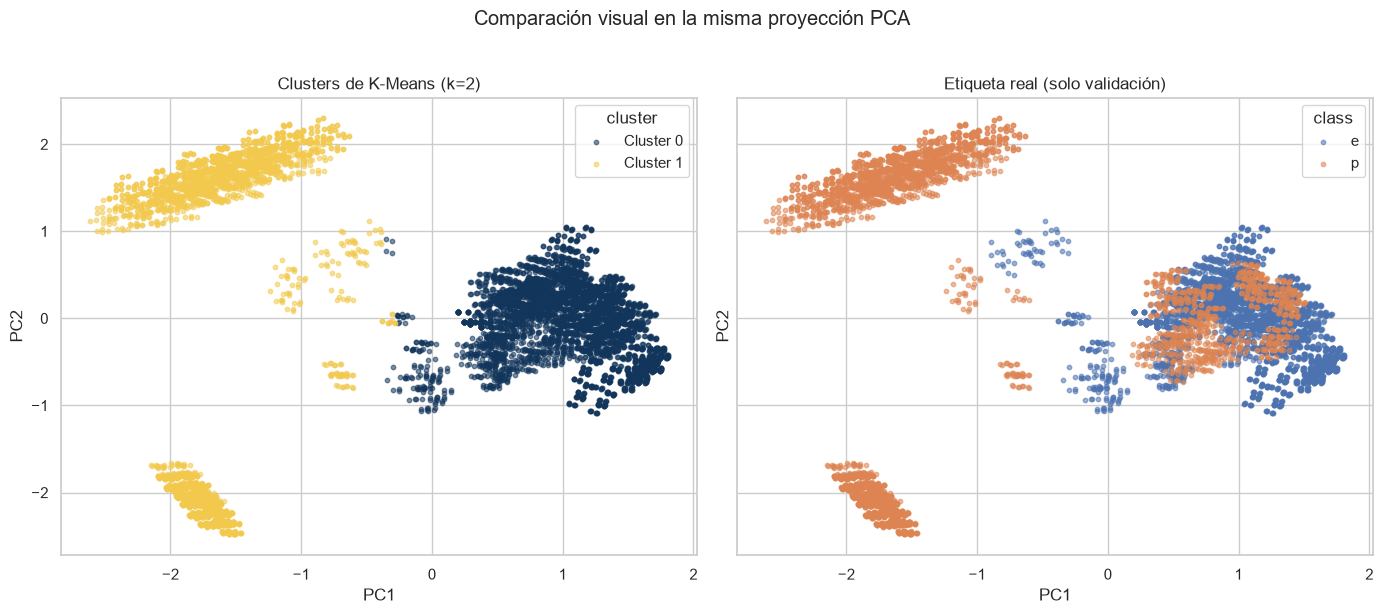

In [35]:
pca_final_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)
X_final_2d = pca_final_2d.fit_transform(
    X_encoded.astype(np.float32)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
cluster_palette = {0: "#12355B", 1: "#F2C94C"}
for cluster_id, color in cluster_palette.items():
    cluster_mask = kmeans_labels == cluster_id
    axes[0].scatter(
        X_final_2d[cluster_mask, 0],
        X_final_2d[cluster_mask, 1],
        color=color,
        s=10,
        alpha=0.55,
        label=f"Cluster {cluster_id}"
    )
axes[0].set_title("Clusters de K-Means (k=2)")
axes[0].legend(title="cluster")

class_palette = {"e": "#4C72B0", "p": "#DD8452"}
for class_name, color in class_palette.items():
    class_mask = y.to_numpy() == class_name
    axes[1].scatter(
        X_final_2d[class_mask, 0],
        X_final_2d[class_mask, 1],
        color=color,
        s=10,
        alpha=0.55,
        label=class_name
    )
axes[1].set_title("Etiqueta real (solo validación)")
axes[1].legend(title="class")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

fig.suptitle("Comparación visual en la misma proyección PCA", y=1.02)
plt.tight_layout()
plt.show()

#### Interpretación de la comparación visual

K-Means identifica correctamente varias regiones dominadas por setas venenosas, pero en la zona central agrupa observaciones de ambas clases. Ese solapamiento explica por qué ARI y NMI son buenos pero no perfectos.

La visualización respalda las métricas, pero no permite evaluarlas por sí sola porque solo representa dos componentes.

## Detección de anomalías con Isolation Forest

Isolation Forest busca observaciones que se aíslan con pocas divisiones aleatorias. No identifica errores automáticamente: señala combinaciones poco frecuentes que merecen revisión.

Fijamos `contamination=0.02`, una hipótesis explícita de que aproximadamente el 2 % de las setas pueden considerarse atípicas. El resultado depende de esta elección.

Anomalías detectadas: 161
Porcentaje: 1.98%
Score mínimo/máximo: -0.0347 / 0.1415


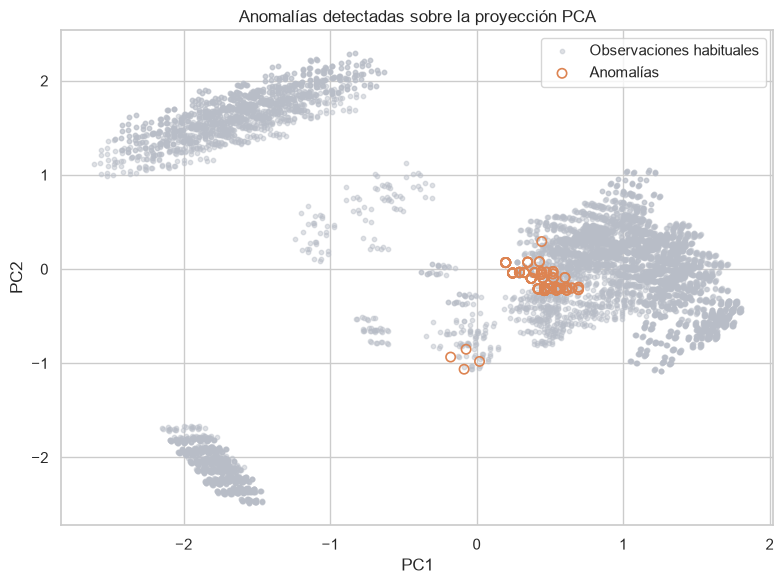

In [36]:
isolation_forest = IsolationForest(
    contamination=0.02,
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
anomaly_labels = isolation_forest.fit_predict(X_reduced)
anomaly_scores = isolation_forest.decision_function(X_reduced)
is_anomaly = anomaly_labels == -1

print(f"Anomalías detectadas: {int(is_anomaly.sum())}")
print(f"Porcentaje: {is_anomaly.mean():.2%}")
print(f"Score mínimo/máximo: {anomaly_scores.min():.4f} / {anomaly_scores.max():.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    X_final_2d[~is_anomaly, 0],
    X_final_2d[~is_anomaly, 1],
    color="#B8BDC7",
    s=10,
    alpha=0.45,
    label="Observaciones habituales"
)
ax.scatter(
    X_final_2d[is_anomaly, 0],
    X_final_2d[is_anomaly, 1],
    facecolors="none",
    edgecolors="#DD8452",
    s=45,
    linewidth=1.2,
    label="Anomalías"
)
ax.set(
    title="Anomalías detectadas sobre la proyección PCA",
    xlabel="PC1",
    ylabel="PC2"
)
ax.legend()
plt.tight_layout()
plt.show()

#### Interpretación de las anomalías

Isolation Forest marca **161 observaciones (1,98 %)** como anómalas, valor coherente con `contamination=0.02`. La mayoría se concentra en regiones concretas de la proyección, aunque PCA 2D no muestra todas las dimensiones utilizadas por el detector.

Estas observaciones no son necesariamente errores ni setas peligrosas: son combinaciones de categorías poco habituales según el modelo y deberían revisarse antes de tomar decisiones.

## Conclusiones

Este notebook muestra que el éxito del aprendizaje no supervisado depende tanto de la representación y de la distancia como del algoritmo.

- La limpieza conserva las 8.124 observaciones, imputa `stalk-root` y elimina `veil-type`, que era constante.
- One-Hot Encoding transforma 21 variables categóricas en 115 columnas binarias sin imponer un orden artificial.
- Random Forest alcanza accuracy **1,0000**; con solo 10 componentes PCA mantiene **0,9996**. Esta es una referencia supervisada, no un resultado de clustering.
- Diez componentes conservan el **64,52 %** de la varianza y ofrecen una representación compacta para comparar modelos.
- t-SNE muestra vecindades locales asociadas con `class`, pero no demuestra por sí solo que exista una partición única.
- Silhouette prefiere **k=7**, mientras que K-Means con `k=2` obtiene **ARI=0,6171** y **NMI=0,5663**. La estructura interna es más detallada que la etiqueta binaria.
- Entre los modelos con dos clusters, K-Means logra el mejor silhouette y ARI; el aglomerativo consigue el NMI más alto.
- En DBSCAN, Jaccard mejora ARI y NMI frente a la distancia euclídea, pero ambas variantes descubren numerosos subgrupos y no dos clases.
- Isolation Forest identifica 161 candidatos atípicos, un **1,98 %**, condicionado por la contaminación fijada.

La etiqueta `class` nunca se utilizó para construir los clusters: únicamente permitió validarlos a posteriori mediante ARI y NMI. Los resultados cuantitativos ejecutados arriba deben guiar la elección final; no existe un algoritmo universalmente mejor.